# POPCON — SPARC PRD (cfspopcon reproduction)

Batched popcon scan of the fusdb transcription of cfspopcon's SPARC PRD case.
Every grid point holds the inputs exactly, solves the free core (`P_aux`), and is
individually certified. The datasheet performance entries (`P_fus`, `Q`, `W_th`, …)
are released first — a scan derives them, so supplying them would over-determine
every off-nominal point.

Two figures, built to be **structurally similar** to cfspopcon's reference plots in
`tests/cfspopcon_SPARC/output/` (`plot_popcon.png`, `plot_remapped.png`):

1. **`<T_e>` vs `<n_e>`** — filled colour is `Q`, with iso-contours for `Q`,
   `P_SOL/P_LH`, `P_aux,launched`, and `P_fus`.
2. **`P_RF` (launched auxiliary power) vs `<n_e>`** — the *same scan remapped* so the
   x-axis becomes `P_aux_launched`; filled colour `Q`, iso-contours `Q`,
   `P_SOL/P_LH`, `P_aux`, `P_fus`.

**Profile peaking.** With flat profiles the DT reactivity (steeply nonlinear in
`T_i`) is badly under-fed, so `P_fus` is far too low and the plasma never nears
ignition (`Q` capped ≈ 3). The setup cell turns on fusdb's parabolic
`(1−ρ²)^α` profile generators; `T_i` tracks the scanned `<T_e>`, so the core now
peaks to ~2× `<T_e>` and the plasma **ignites** (`P_aux → 0`, `Q → ∞`) over the
top-left of the grid, matching cfspopcon's structure. `Q` is saturated at 50 for
display; `P_fus` at the PRD point is ≈ 130 MW (cfspopcon: 116) and `Q_max ≈ 28`
(cfspopcon: ≈ 22).

Notes: peaking is capped at 2.0 rather than cfspopcon's 2.5 — at 2.5 the stored
energy stiffens the batched confinement solve past convergence. `P_SOL/P_LH` is
formed as `(P_loss − P_rad)/P_LH` (cfspopcon's `P_in` ≙ fusdb `P_loss`; `P_sep`
has no standalone provider). The reference's `t_flattop` contour is omitted — it
needs the full central-solenoid flux-consumption chain, not tractable to reconcile
per point across the whole scan.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
while root != root.parent and not (root / "src" / "fusdb").is_dir():
    root = root.parent
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))

from fusdb.reactor import Reactor
from fusdb.variable import Variable
from fusdb.plotting import plot_popcon

reactor = Reactor.from_yaml(root / "tests" / "cfspopcon_SPARC" / "reactor_popcon.yaml")
# Release the datasheet performance/derived entries (the scan computes them) and
# the pinned non-DT fusion channels: with peaked profiles the hot core makes
# their power non-negligible, so let them be computed rather than held at 0.
for name in ("eps", "S_p", "P_fus", "Q", "W_th", "P_e_net",
             "P_fus_DD", "P_fus_DHe3", "P_fus_TT", "P_fus_DDn_n"):
    variable = reactor.get_variable(name)
    if variable is not None:
        del reactor.variables[variable.name]

# Two cfspopcon-PRD inputs the popcon config omits, added here so the SOL/exhaust
# fields the plots need become derivable per point:
#   * fraction_of_external_power_coupled -> activates P_aux_launched (P_RF)
#   * separatrix_elongation              -> activates P_sync -> P_rad (hence P_SOL)
reactor.add_variable(Variable("fraction_of_external_power_coupled", value=0.9))
reactor.add_variable(Variable("separatrix_elongation", value=1.96875))

# --- Activate profile peaking -------------------------------------------------
# The reconcile/popcon path otherwise fills the fusion-relevant profiles FLAT
# (peak/avg = 1), which badly under-states P_fus (the DT reactivity is steeply
# nonlinear in T_i) and keeps the plasma far from ignition. Turn on fusdb's
# parabolic (1-rho^2)^alpha profile generators for T_e, T_i and n_e; T_i tracks
# the scanned <T_e> through T_i_avg, and n_i follows n_e via the fuel fractions.
#   * temperature_peaking = 2.0: the core reaches ~2x <T_e> and the plasma
#     ignites over part of the grid, while the stored energy stays within reach
#     of the batched confinement solve (2.5 over-stiffens it and diverges).
#   * density_peaking = 1.4 (supplied, so the Angioni collisionality scaling is
#     excluded to avoid double-controlling it).
reactor.add_variable(Variable("temperature_peaking", value=2.0))
reactor.add_variable(Variable("ion_temperature_peaking", value=2.0))
reactor.add_variable(Variable("density_peaking", value=1.4))
reactor.relation_include = [
    "Parabolic electron temperature profile",
    "Parabolic ion temperature profile",
    "Parabolic electron density profile",
]
reactor.relation_exclude = ["Electron density peaking (Angioni)"]
reactor.name

'SPARC PRD popcon (cfspopcon)'

In [2]:
import time

t0 = time.perf_counter()
result = reactor.popcon(
    x={"variable": "average_electron_temp", "start": 5.0, "stop": 20.0, "num": 34},
    y={"variable": "average_electron_density", "start": 2.0e19, "stop": 40.0e19, "num": 30},
    outputs=(
        "P_fus",
        "P_aux",
        "P_aux_launched",  # launched RF power -> plot 2 x-axis
        "Q_sci",
        "P_loss",          # cfspopcon P_in
        "P_rad",           # P_SOL = P_loss - P_rad
        "P_LH",
        "f_GW",
    ),
)
print(f"{result['termination']} in {time.perf_counter() - t0:.0f}s")
payload = result["popcon"]

popcon scan completed: 1020/1020 points solved in 79s


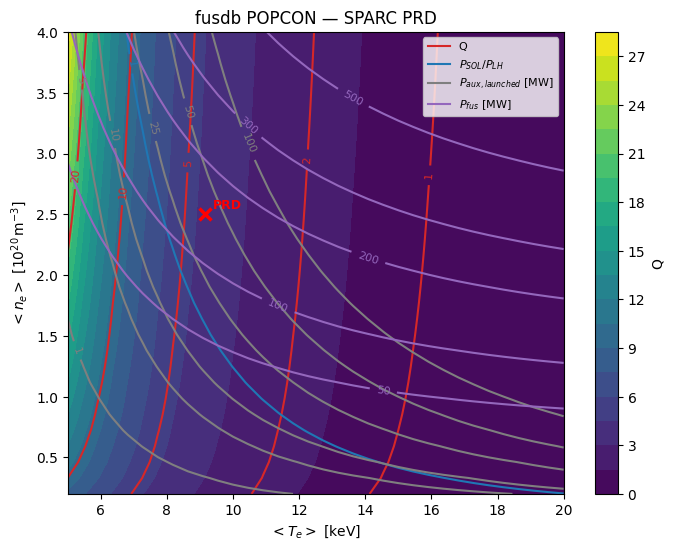

In [3]:
# --- Derive the plot fields from the scan (shared by both figures) ---
f = payload["fields"]
Te = np.asarray(payload["x"]["values"], float)           # <T_e> [keV]
ne20 = np.asarray(payload["y"]["values"], float) / 1e20  # <n_e> [1e20 m^-3]
success = np.asarray(payload["success"], bool)

# With peaked profiles the plasma reaches ignition (P_aux -> 0), where Q -> inf;
# saturate Q at 50 for display, as cfspopcon's reference plot does.
Q = np.minimum(f["Q_sci"], 50.0)
P_fus_MW = f["P_fus"] / 1e6
P_aux_launched_MW = f["P_aux_launched"] / 1e6
# cfspopcon: P_SOL = P_in - P_rad, and cfspopcon's P_in is fusdb's P_loss.
P_SOL_over_P_LH = (f["P_loss"] - f["P_rad"]) / f["P_LH"]

# Semantic colours matching the cfspopcon reference plots.
COLORS = {
    "Q": "tab:red",
    "$P_{SOL}/P_{LH}$": "tab:blue",
    "$P_{aux,launched}$ [MW]": "tab:gray",
    "$P_{aux}$ [MW]": "tab:gray",
    "$P_{fus}$ [MW]": "tab:purple",
}
PRD = (9.13793, 2.5)  # (<T_e> [keV], <n_e> [1e20 m^-3])

# --- Plot 1: <T_e> vs <n_e> ---
display = {
    "x": {"name": "$<T_e>$ [keV]", "values": Te},
    "y": {"name": "$<n_e>$ [$10^{20}\\,\\mathrm{m^{-3}}$]", "values": ne20},
    "success": success,
    "fields": {
        "Q": Q,
        "$P_{SOL}/P_{LH}$": P_SOL_over_P_LH,
        "$P_{aux,launched}$ [MW]": P_aux_launched_MW,
        "$P_{fus}$ [MW]": P_fus_MW,
    },
}
ax = plot_popcon(
    display,
    fill="Q",
    contours=("Q", "$P_{SOL}/P_{LH}$", "$P_{aux,launched}$ [MW]", "$P_{fus}$ [MW]"),
    levels={
        "Q": [1, 2, 5, 10, 20, 50],
        "$P_{SOL}/P_{LH}$": [1.0],
        "$P_{aux,launched}$ [MW]": [1, 5, 10, 25, 50, 100],
        "$P_{fus}$ [MW]": [50, 100, 200, 300, 500],
    },
    colors=COLORS,
    title="fusdb POPCON — SPARC PRD",
)
ax.plot(*PRD, "x", color="red", ms=9, mew=2.5, zorder=5)
ax.annotate("PRD", PRD, textcoords="offset points", xytext=(6, 4),
            color="red", fontsize=9, fontweight="bold")
ax.figure.set_size_inches(8, 6)
plt.show()

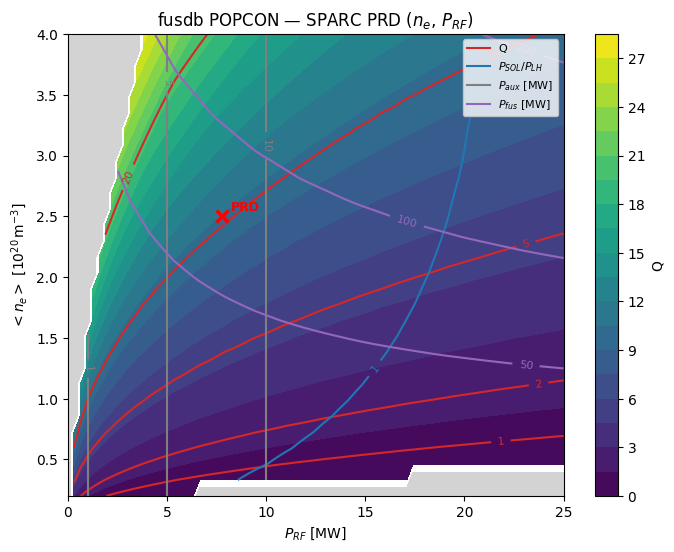

In [4]:
# --- Plot 2: remap the scan onto a P_RF (launched auxiliary power) x-axis ---
def remap_x(source_x, fields, new_x):
    """Interpolate every field from the <T_e> samples onto ``new_x`` using
    ``source_x`` (here P_aux_launched, MW) as the new coordinate, row by row at
    fixed <n_e>. Points outside a row's achievable P_RF range become NaN."""
    ny = source_x.shape[0]
    out = {name: np.full((ny, new_x.size), np.nan) for name in fields}
    for iy in range(ny):
        row_x = source_x[iy]
        good = np.isfinite(row_x)
        if good.sum() < 2:
            continue
        xs = row_x[good]
        order = np.argsort(xs)
        xs = xs[order]
        keep = np.concatenate(([True], np.diff(xs) > 0))  # strictly increasing
        xs = xs[keep]
        if xs.size < 2:
            continue
        in_range = (new_x >= xs[0]) & (new_x <= xs[-1])
        for name, arr in fields.items():
            ys = arr[iy][good][order][keep]
            row = np.full(new_x.size, np.nan)
            row[in_range] = np.interp(new_x, xs, ys)[in_range]
            out[name][iy] = row
    return out

P_RF = np.linspace(0.0, 25.0, 80)  # launched RF power [MW]
remapped = remap_x(
    P_aux_launched_MW,
    {
        "Q": Q,
        "$P_{SOL}/P_{LH}$": P_SOL_over_P_LH,
        "$P_{aux}$ [MW]": P_aux_launched_MW,
        "$P_{fus}$ [MW]": P_fus_MW,
        "success": success.astype(float),
    },
    P_RF,
)
remapped_success = remapped.pop("success") > 0.5

display_remapped = {
    "x": {"name": "$P_{RF}$ [MW]", "values": P_RF},
    "y": {"name": "$<n_e>$ [$10^{20}\\,\\mathrm{m^{-3}}$]", "values": ne20},
    "success": remapped_success,
    "fields": remapped,
}
ax = plot_popcon(
    display_remapped,
    fill="Q",
    contours=("Q", "$P_{SOL}/P_{LH}$", "$P_{aux}$ [MW]", "$P_{fus}$ [MW]"),
    levels={
        "Q": [1, 2, 5, 10, 20, 50],
        "$P_{SOL}/P_{LH}$": [1.0],
        "$P_{aux}$ [MW]": [1, 5, 10, 25],
        "$P_{fus}$ [MW]": [50, 100, 200, 300, 500],
    },
    colors=COLORS,
    title="fusdb POPCON — SPARC PRD ($n_e$, $P_{RF}$)",
)
ax.plot(7.8, 2.5, "x", color="red", ms=9, mew=2.5, zorder=5)
ax.annotate("PRD", (7.8, 2.5), textcoords="offset points", xytext=(6, 4),
            color="red", fontsize=9, fontweight="bold")
ax.figure.set_size_inches(8, 6)
plt.show()